# CFTP & Bounding Chain algorithm for a disordered spin system

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import networkx as nx

# configuration of matplotlib for better visualization and paper-quality figures
plt.rcParams.update({
    'figure.figsize': (8, 6),
    'font.size': 22,
    'lines.linewidth': 4,
    'axes.grid': True,
    'legend.fontsize': 12,
    'xtick.major.size': 5,
    'ytick.major.size': 5,
    'xtick.minor.size': 3,
    'ytick.minor.size': 3,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'lines.markersize': 10,
    'font.family': 'serif',
    'font.serif': ['Latin Modern Roman'],
    'mathtext.fontset': 'cm',
    'axes.spines.top': False,
    'axes.spines.right': False,
    # remove the box around the legend
    'legend.frameon': False
})

## Setting

Let $G=(V, E)$ a graph. For each $(u, v) \in E$ we define the random variable called _coupling_ $J_{uv}$. For each $v\in V$ define $x(v)\in\{-1, +1\}$. We call $x(v)$ a spin. The _energy_ of a configuration is given by $U(x) = - \sum_{(u,v)\in E} J_{uv}x(u)x(v)$. We define the Gibbs-Boltzmann measure at inverse temperature $\beta$ :

$$\pi_\beta(x) = \frac1{Z_\beta} e^{-\beta U(x)}  \, , \, Z_\beta = \sum_x e^{-\beta U(x)}$$


The Gibbs-Boltzmann measure is also called the equilibrium measure. We want to be able to sample configurations from it. To do so, we aim at using the Coupling From The Past algorithm proposed by Propp and Wilson [insert ref].

Let $(X_n)$ be a Markov Chain of state space $S = \{-1, +1\}^{|V|} = C^{|V|}$. Let the functionnal representation of the Markov Chain be 

$$ 
X_{n+1}(v) = \phi(X_n(v), v_n, r_n, s_n) = \left\lbrace \begin{matrix} X_n(v) \text{ if } v\neq v_n \\ X_n(v) \text{ if } X_n(v)=s_n \\ -X_n(v) \text{ if } X_n(v)=-s_n \text{ and } r< F_\beta(2x(v)h(x, v)) \\ X_n(v) \text{ if } X_n(v)=-s_n \text{ and } r\geq F_\beta(2x(v)h(x,v)) \end{matrix}\right.
$$

where $v_n\sim \text{Unif}(V)$, $s_n\sim\text{Unif}(\{-1, +1\})$, $r_n\sim\text{Unif}([0, 1])$ and 

$$
F_\beta(2x(v)h(x,v)) = \left\lbrace \begin{matrix}  \frac1{1+e^{\beta 2x(v)h(x,v)}} \text{, Glauber Heat Bath} \\ \min(1, e^{-\beta 2x(v)h(x,v)})\text{, Metropolis-Hastings} \end{matrix}\right.
$$

In what preceed, $h(x,v)=\sum_{u\in N(v)} J_{uv}x(u)$ and $N(v)=\{u\in V\,|\, (u,v)\in E\}$.

We define the bounding chain $(Y_n)$ with state space $S' = \{-1, +1, \star\}^{|V|}=C'^{|V|}$ with $\star = \{-1, +1\}$. The update of $(Y_n)$ is done by applying the following algorithm :


1. Start with $Y_0 = \star$
2. For $n\leq$ max_iter:
    1. Draw $v_n$, $r_n$, $s_n$
    2. If $Y_n(v_n) = s_n$
        1. $Y_{n+1}(v_n) = Y_n(v_n)$
    3. If $Y_n(v_n) = -s_n$
        1. Compute $\hbar(Y_n, v_n) = \sum_{u\in N(v_n)} J_{u v_n}\bold 1_{\{ Y_n(u)\neq\star \}} $ and $m(Y_n, v_n) = \sum_{u\in N(v_n)}|J_{u v_n}|\bold 1_{\{Y_n(u) = \star\}}$
        2. Compute $h^+ = \hbar(Y_n, v_n) + m(Y_n, v_n)$ and $h^- = \hbar(Y_n, v_n) - m(Y_n, v_n)$
        3. If $r_n < F_\beta(-2s_nh^{s_n})$
            1. $Y_{n+1}(v_n) = s_n$
        4. Else If $F_\beta(-2s_nh^{s_n})<r_n<F_\beta(-2s_nh^{-s_n})$
            1. $Y_{n+1}(v_n) = \star$
        5. Else If $r_n > F_\beta(-2s_nh^{-s_n})$
            1. $Y_{n+1}(v_n) = Y_n(v_n) = -s_n$.
    4. If $Y_n(v_n)=\star$
        1. Compute $\hbar(Y_n, v_n) = \sum_{u\in N(v_n)} J_{u v_n}\bold 1_{\{ Y_n(u)\neq\star \}} $ and $m(Y_n, v_n) = \sum_{u\in N(v_n)}|J_{u v_n}|\bold 1_{\{Y_n(u) = \star\}}$
        2. Compute $h^+ = \hbar(Y_n, v_n) + m(Y_n, v_n)$ and $h^- = \hbar(Y_n, v_n) - m(Y_n, v_n)$
        3. If $r_n < F_\beta(-2s_nh^{s_n})$
            1. $Y_{n+1}(v_n) = s_n$
        4. Else If $F_\beta(-2s_nh^{s_n})<r_n<F_\beta(-2s_nh^{-s_n})$
            1. $Y_{n+1}(v_n) = Y_n(v_n) = \star$
        5. Else If $r_n > F_\beta(-2s_nh^{-s_n})$
            1. $Y_{n+1}(v_n) = Y_n(v_n) = \star$.

The Bounding Chain is then used as the Markov Chain for the CFTP. To do so we start from a long time in the past $-T$ and simulate the chain forward using the previous algorithm. We check at $T=0$ that $|Y_0(v_n)| = 1$ for all $v\in V$. If this is not the case, we start from further back in the past. At each timestep $t\in[-T, 0]$ the same random numbers $r_t\, s_t$ and random node $v_t$ are used so that the same chain is simulated at each iteration of the CFTP algorithm.

In [183]:
def F_beta_Glauber(beta, U):
    return 1 / (1 + np.exp(2 * beta * U))

def F_beta_Metropolis(beta, U):
    if U <= 0:
        return 1
    else:
        return np.exp(-2 * beta * U)

def CFTP_BC_disordered(beta, G, coupling):
    t = -1
    random_node = []
    random_spin_value = []
    random_real = []
    N = G.number_of_nodes()
    while t > -2**15:
        Y = [[-1, +1] for _ in range(N)]  # Initialize the bounding chains to cover all configurations
        for timestep in range(t, 1):
            while len(random_real) < -t:
                random_real.append(np.random.rand())  # Generate random numbers for updates
                random_node.append(np.random.randint(N))
                random_spin_value.append(np.random.choice([-1, 1]))
            actual_random_node = random_node[-timestep-1]
            actual_random_spin_value = random_spin_value[-timestep-1]
            actual_random_real = random_real[-timestep-1]
            # print("Timestep:", timestep, "Random Node:", actual_random_node, "Random Spin Value:", actual_random_spin_value, "Random Real:", actual_random_real)
            if Y[actual_random_node] == [actual_random_spin_value]:
                continue
            elif Y[actual_random_node] == [-actual_random_spin_value]:
                h_bar = 0
                m = 0
                for neighbor in G.neighbors(actual_random_node):
                    if Y[neighbor] != [-1, +1]:
                        h_bar += coupling[actual_random_node, neighbor]
                    else:
                        m += np.abs(coupling[actual_random_node, neighbor])
                h_plus = h_bar + actual_random_spin_value*m
                h_minus = h_bar - actual_random_spin_value*m
                if actual_random_real < F_beta_Metropolis(beta, -2*actual_random_spin_value*h_plus):
                    Y[actual_random_node] = [actual_random_spin_value]
                elif actual_random_real > F_beta_Metropolis(beta, -2*actual_random_spin_value*h_plus) and actual_random_real < F_beta_Metropolis(beta, -2*actual_random_spin_value*h_minus):
                    Y[actual_random_node] = [-1, +1]
                elif actual_random_real > F_beta_Metropolis(beta, -2*actual_random_spin_value*h_minus):
                    Y[actual_random_node] = [-actual_random_spin_value]
            elif Y[actual_random_node] == [-1, +1]:
                h_bar = 0
                m = 0
                for neighbor in G.neighbors(actual_random_node):
                    if Y[neighbor] != [-1, +1]:
                        h_bar += coupling[actual_random_node, neighbor]
                    else:
                        m += np.abs(coupling[actual_random_node, neighbor])
                h_plus = h_bar + actual_random_spin_value*m
                h_minus = h_bar - actual_random_spin_value*m
                if actual_random_real < F_beta_Metropolis(beta, -2*actual_random_spin_value*h_plus):
                    Y[actual_random_node] = [actual_random_spin_value]
                else:
                    Y[actual_random_node] = [-1, +1]
                # elif actual_random_real > F_beta_Glauber(beta, -2*actual_random_spin_value*h_plus) and actual_random_real < F_beta_Glauber(beta, -2*actual_random_spin_value*h_minus):
                #     Y[actual_random_node] = [-1, +1]
                # elif actual_random_real > F_beta_Glauber(beta, -2*actual_random_spin_value*h_minus):
                #     Y[actual_random_node] = [-1, +1]
        # Check for coalescence
        if all(len(Y[v])==1 for v in range(N)):
            return np.array([Y[v][0] for v in range(N)]), t  # Return the coalesced configuration
        else:
            t *= 2  # Double the time window for the next iteration
    print("Warning: CFTP did not coalesce after a large number of iterations.")
    return None, np.nan

## Test on Erdös-Rényi graph
For this test we use an Erdös-Rényi graph so that the random coupling are identified to $J_{uv} = 1$ if $(u,v)\in E$ and 0 otherwise.

Time for Coalescence: 128


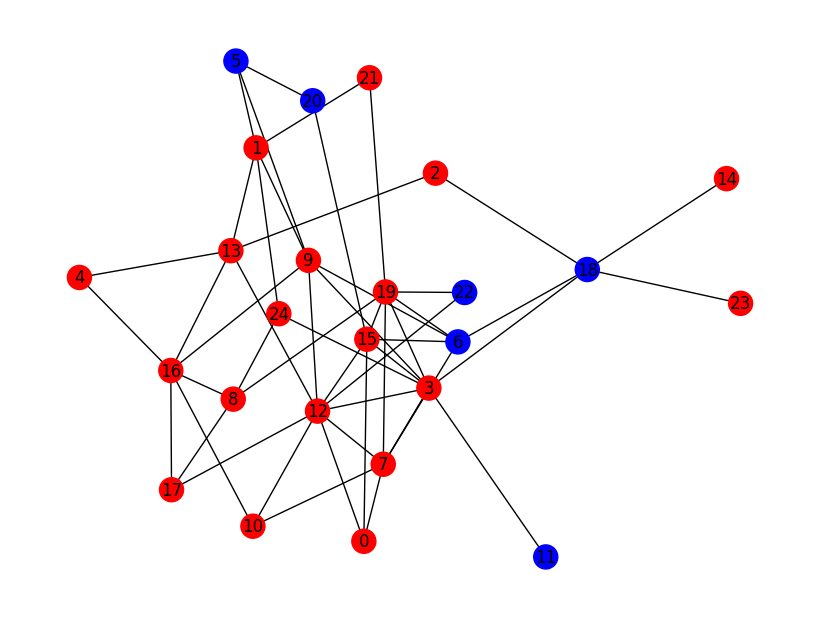

In [184]:
G = nx.erdos_renyi_graph(25, 0.2)  # Create a random graph with 25 nodes and edge probability of 0.2
couplings = np.random.uniform(-1, 1, size=(G.number_of_nodes(), G.number_of_nodes()))  # Random couplings between -1 and 1
beta = 1.0  # Inverse temperature
config, time = CFTP_BC_disordered(beta=beta, G=G, coupling=couplings)

# Display the resulting configuration and the time taken for coalescence
print("Time for Coalescence:", -time)
# Show the graph with the final configuration as node colors

color_map = ['red' if config[v] == 1 else 'blue' for v in G.nodes()]
nx.draw(G, node_color=color_map, with_labels=True)
plt.show()

## Test on the Curie-Weiss model

We use a fully connected graph with all couplings equal to 1/N

In [185]:
from scipy.special import factorial

def partition_function(beta, N):
    val_m = np.arange(-N, N+1, 2) / N  # Possible magnetization values
    Z = 0
    for m in val_m:
        km = N/2*(1+m)  # Number of +1 spins
        prefac = factorial(N) / (factorial(km) * factorial(N - km))
        energy = -N * m**2 / 2 
        Z += prefac * np.exp(-beta * energy)
    return Z

def theoretical_magnetization(beta, N):
    val_m = np.arange(-N, N+1, 2) / N  # Possible magnetization values
    mag_sum = 0
    for m in val_m:
        km = N/2*(1+m)  # Number of +1 spins
        prefac = factorial(N) / (factorial(km) * factorial(N - km))
        energy = -N * m**2 / 2 
        mag_sum += prefac * np.abs(m) * np.exp(-beta * energy)
    return mag_sum/partition_function(beta, N)

def theoretical_magnetization_variance(beta, N):
    val_m = np.arange(-N, N+1, 2) / N  # Possible magnetization values
    mean_mag = 0
    mean_mag_square = 0
    for m in val_m:
        km = N/2*(1+m)  # Number of +1 spins
        prefac = factorial(N) / (factorial(km) * factorial(N - km))
        energy = -N * m**2 / 2  # Energy per particle
        mean_mag += prefac * np.abs(m) * np.exp(-beta * energy)
        mean_mag_square += prefac * np.abs(m)**2 * np.exp(-beta * energy)
    mean_mag = mean_mag/partition_function(beta, N)
    mean_mag_squared = mean_mag_square/partition_function(beta, N)
    return mean_mag_squared - mean_mag**2

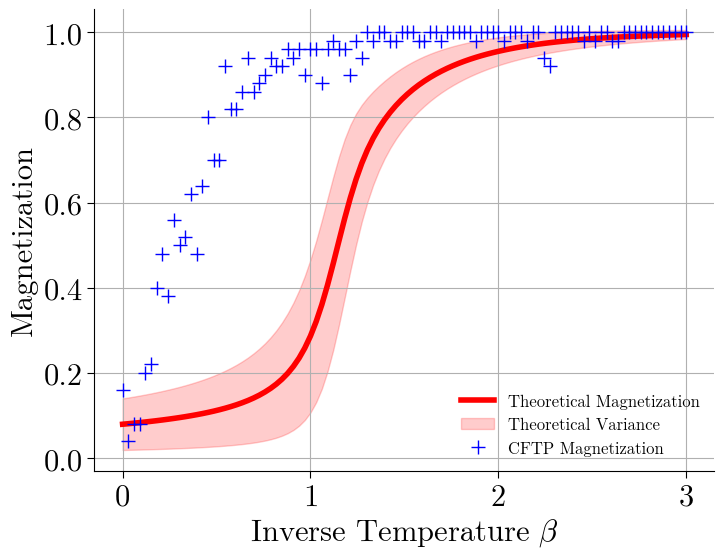

In [186]:
# use a fully connected graph with all couplings equal to 1/N, where N is the number of nodes in the graph
G = nx.complete_graph(100)  # Create a complete graph with 25 nodes
couplings = (np.ones((G.number_of_nodes(), G.number_of_nodes())) - np.eye(G.number_of_nodes())) / G.number_of_nodes()
# beta = 1  # Inverse temperature
# config, time = CFTP_BC_disordered(beta=beta, G=G, coupling=couplings)
# print("Time for Coalescence:", -time)
# color_map = ['red' if config[v] == 1 else 'blue' for v in G.nodes()]
# nx.draw(G, node_color=color_map, with_labels=True)
# plt.show()

# Compute the magnetization of the resulting configuration for different values of beta
betas = np.linspace(0, 3.0, 100)
magnetizations = []
theoretical_magnetizations = [theoretical_magnetization(b, G.number_of_nodes()) for b in betas]
theoretical_magnetization_variances = [theoretical_magnetization_variance(b, G.number_of_nodes()) for b in betas]
for beta in betas:
    config, time = CFTP_BC_disordered(beta=beta, G=G, coupling=couplings)
    magnetization = np.abs(np.mean(config))  # Average spin value as magnetization
    magnetizations.append(magnetization)
plt.plot(betas, theoretical_magnetizations, '-r', label='Theoretical Magnetization')
plt.fill_between(betas, np.array(theoretical_magnetizations) - np.sqrt(theoretical_magnetization_variances),
                 np.array(theoretical_magnetizations) + np.sqrt(theoretical_magnetization_variances), color='red', alpha=0.2, label='Theoretical Variance')
plt.plot(betas, magnetizations, '+b', label='CFTP Magnetization')
plt.xlabel(r'Inverse Temperature $\beta$')
plt.ylabel('Magnetization')
plt.legend()
plt.show()